# Computation on numpy arrays : Universal functions
```the reasons that numpy is so important in the data science world ```

# Aggregations :Min, Max, and everything in between 
* NumPy has fast built-in aggregation functions for working on arrays

In [ ]:
import numpy as np 

In [ ]:
l = np.array (range (10))
print(sum(l))
print(np.sum(l)) #computed much more quickly 

In [ ]:
big_array = np.random.rand(1000000)
%timeit sum(big_array)

In [ ]:
%timeit np.sum(big_array)

## minimum and maximum

In [ ]:
min(big_array), max(big_array)

In [ ]:
np.min(big_array), np.max(big_array)

In [ ]:
%timeit min(big_array)

In [ ]:
%timeit np.min(big_array)

In [ ]:
%timeit big_array.min() # a shorter syntax 

In [ ]:
print(big_array.min(), big_array.max(), big_array.sum())

```Whenever possible, make sure that you are using the NumPy version of these aggre‐gates when operating on NumPy arrays!```

## Multidimentional aggregates 

In [ ]:
m = np.random.rand(3, 4)
m

* By default, each NumPy aggregation function will return the aggregate over the entirearray:

In [ ]:
m.sum()

In [ ]:
m.sum(axis = 0)

* Aggregation functions take an additional argument specifying the axis along which
the aggregate is computed. For example, we can find the minimum value within each
column by specifying axis=0:
      ``` m.min(axis = 0)```

In [ ]:
m.min(axis = 0)

In [ ]:
# we can find the maximum value within each row:
m.max (axis = 1)

### So specifying axis=0 means that the first axis will be collapsed: for two-dimensional arrays, this means that values within each column will be aggregated.

In [ ]:
m.mean() # Compute median of elements

In [ ]:
m.std() #Compute standard deviatioN

In [ ]:
m.var() #Compute variance

In [ ]:
m.argmin() #Find index of minimum value

In [ ]:
m.argmax()

In [ ]:
m.percentile() #!!!!!!!!!!!!

In [ ]:
m.any() #Evaluate whether any elements are true

In [ ]:
m.all() #Evaluate whether all elements are true

In [ ]:
import pandas as pd 

In [ ]:
data = pd.read_csv('president_heights.csv')

In [ ]:
height = np.array(data['height(cm)'])

In [ ]:
print(height)

In [ ]:
print("Mean height:", height.mean())
print("Standard deviation:", height.std())
print("Minimum height:", height.min())
print("Maximum height:", height.max())

In [ ]:
print("25th percentile:", np.percentile(height, 25))

### 75th Percentile Calculation
Calculates the **75th percentile** (3rd quartile) of the `height` dataset using `np.percentile()`.
* **Interpretation:** 75% of the data values are less than or equal to this number.

In [ ]:
# Calculate and print the 75th percentile (Q3) of heights
# Meaning: 75% of the values in 'height' are less than or equal to this result
print("75th percentile:", np.percentile(height, 75))

### Why Use Percentiles & When to Apply Them

**Key Benefits:**
* **Robust to Outliers:** Unlike the mean, percentiles reflect the true distribution without being distorted by extreme values.
* **Benchmarking:** Helps measure relative standing (e.g., scoring in the 75th percentile means beating 75% of the data).
* **Outlier Detection:** Serves as the foundation for calculating the Interquartile Range (IQR = Q3 - Q1) to catch anomalies.

**When to Use:**
* **Exploratory Data Analysis (EDA):** To understand data spread and build Box Plots.
* **Skewed Datasets:** Ideal for salary distributions, housing prices, or server response times where averages can lie.

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt 
import seaborn; seaborn.set()

In [ ]:
plt.hist(height)

In [ ]:
plt.hist(height)
plt.title('Height Distribution of US presidents')
plt.xlabel('height(cm)')
plt.ylabel('number')

# Computation on Arrays: Broadcasting

### NumPy Broadcasting Overview

* **Definition:** A set of rules in NumPy that allows binary functions (`+`, `-`, `*`, etc.) to operate on arrays of **different shapes and sizes**.
* **Key Benefit:** Provides vectorization without requiring explicit Python loops or manual array reshaping/duplication in memory.
* **Core Function:** Automatically aligns array dimensions so element-wise operations can be performed seamlessly.

In [ ]:
a = np.array([0, 1, 2])
b = np.array([3, 4, 5])

a + b

In [ ]:
a + 3 # add a scalar 

In [ ]:
m = np.ones ((3, 3))
m

In [ ]:
m + a 

### 2D Broadcasting with `np.newaxis`

* **Row Vector (`a`):** `a = np.arange(3)` creates shape `(3,)` -> `[0, 1, 2]`.
* **Column Vector (`b`):** `np.newaxis` inserts a new axis, converting shape to `(3, 1)`.
* **Broadcasting Effect:** Adding `a + b` stretches both arrays to shape `(3, 3)` to create a 2D grid/addition matrix.

In [ ]:
a = np.arange (3)
b = np.arange (3)[: , np.newaxis]
b

In [ ]:
print ( a + b )

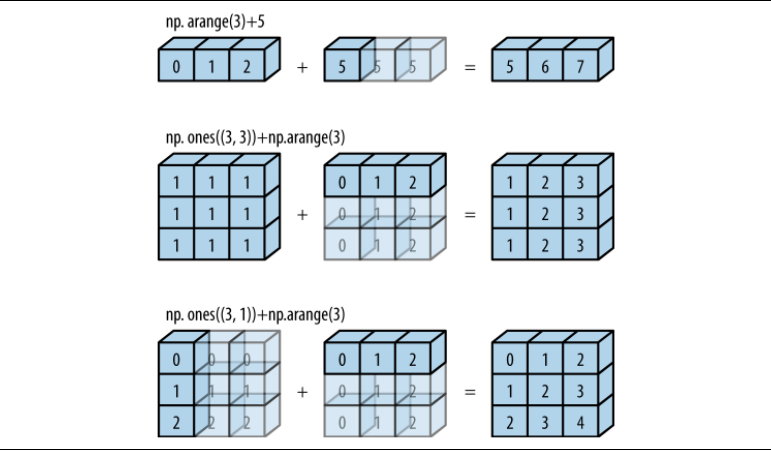

```The light boxes represent the broadcasted values: again, this extra memory is notactually allocated in the course of the operation, but it can be useful conceptually to imagine that it is.```

### Memory Efficiency of Broadcasting

* **Concept vs. Memory:** NumPy does **not** actually duplicate data or allocate extra memory for broadcasted values.
* **Mechanism:** It reuses the existing array values efficiently in memory during computation.
* **Advantage:** Saves significant RAM and significantly speeds up operations on large datasets.

### Rules of Broadcasting in NumPy

NumPy applies three main rules to operate on arrays of different shapes:

1. **Rule 1 (Dimension Padding):** If two arrays differ in their number of dimensions, the shape of the one with fewer dimensions is padded with ones on its **leading (left) side**.
   * *Example:* Shape `(3,)` becomes `(1, 3)`.

2. **Rule 2 (Stretching):** If the shape of the two arrays does not match in a dimension, the array with a shape equal to `1` in that dimension is stretched to match the larger shape.
   * *Example:* Shape `(1, 3)` stretches to match `(3, 3)`.

3. **Rule 3 (Error Triggering):** If in any dimension the sizes are unequal and **neither is equal to 1**, a `ValueError` is raised because the shapes are incompatible.

In [ ]:
import numpy as np

# Rule 1 & 2 Example: Compatible Shapes
M = np.ones((2, 3))  # Shape: (2, 3)
a = np.arange(3)     # Shape: (3,)

# Step 1: 'a' gets padded on the left -> shape (1, 3)
# Step 2: 'a' gets stretched vertically -> shape (2, 3)
result = M + a # Output shape: (2, 3)
print (result)

# Rule 3 Example: Incompatible Shapes (Triggers ValueError)
x = np.ones((3, 2))  # Shape: (3, 2)
y = np.arange(3)     # Shape: (3,) -> padded to (1, 3)
# Step 3: Neither 2 nor 3 equals 1 in the last dimension -> Error!
# try:
#     print(x + y)
# except ValueError as e:
#     print("ValueError:", e)

In [ ]:
np.logaddexp(M, a)

### Centering an Array (Zero-Mean Preprocessing)

* **Concept:** Subtracting the mean of each feature (column) from the dataset so that the mean of the transformed data becomes `0`.
* **Data Representation:** A `(10, 3)` array represents 10 observations with 3 features each.
* **Broadcasting Power:** Subtracting the mean array of shape `(3,)` from the matrix of shape `(10, 3)` automatically stretches the mean across all 10 rows without writing manual Python loops.
* **Use Case:** Crucial data preparation step for algorithms like PCA (Principal Component Analysis) and Feature Scaling.

In [ ]:
# Create a random dataset of 10 observations and 3 features
X = np.random.randint(0, 10, size=(10, 3))

# 1. Compute the mean of each column (axis=0) -> Shape: (3,)
X_mean = X.mean(axis=0)

# 2. Center the array using Broadcasting -> (10, 3) - (3,)
X_centered = X - X_mean

# Verify that the new mean of each column is virtually zero
print("Column Means Before Centering:", X_mean)
print("Column Means After Centering :", X_centered.mean(axis=0))

### Importance and Practical Applications of Data Centering

**Why Center Data?**
* **Equal Footing:** Brings different features to a common baseline ($Mean = 0$).
* **Model Efficiency:** Helps Machine Learning and Neural Network optimization algorithms converge much faster.
* **Algorithm Prerequisite:** Essential for dimension-reduction algorithms like Principal Component Analysis (PCA).

**When to Use It?**
* During the **Data Preprocessing** stage before training ML/DL models.
* When handling features measured in vastly different units or scales (e.g., Age vs. Annual Income).
* In **Image Processing** to normalize brightness across dataset images.

### Plotting 2D Functions Using Broadcasting

* **Grid Generation:** Combining 1D array `x` of shape `(50,)` with column vector `y` of shape `(50, 1)` uses broadcasting to form a `(50, 50)` coordinate grid.
* **Vectorized Computation:** Evaluates $z = f(x, y)$ for all grid points simultaneously without `for` loops or `np.meshgrid`.
* **Visualization (`plt.imshow`):** Renders the 2D matrix `z` as a color heatmap/contour plot over the domain $[0, 5] \times [0, 5]$.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Generate grid values using broadcasting
x = np.linspace(0, 5, 50)                # Shape: (50,)
y = np.linspace(0, 5, 50)[:, np.newaxis]  # Shape: (50, 1)

# 2. Compute 2D function
z = np.sin(x) ** 10 + np.cos(10 + y * x) * np.cos(x)  # Result shape: (50, 50)

# 3. Display as a 2D heatmap
plt.imshow(z, origin='lower', extent=[0, 5, 0, 5], cmap='viridis')
plt.colorbar(label='z values')
plt.xlabel('x')
plt.ylabel('y')
plt.title('2D Function Plot via Broadcasting')
plt.show()